In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [ ]:
import pandas as pd 
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import Scripts_Imane
from Scripts_Imane import Plots
from scipy.stats import norm, shapiro, kstest
import seaborn as sns


In [ ]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/2025_5_phase2_light_status_slope_QtilNorm_randeffONLYPLATES_ontimepoints.csv')
data ['y2_slope'] = data['y2_slope_mixed_centered']

/tmp/ipykernel_457037/1183254351.py:1: DtypeWarning: Columns (333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,376,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/2025_5_phase2_light_status_slope_QtilNorm_randeffONLYPLATES_ontimepoints.csv')


In [18]:
# Add a row for light blocs
data['light_bloc'] = data['light_regime'].apply(
    lambda x: 'HL_Low_freq' if x in ['20h_HL', '20h_ML', '2h-2h'] 
    else 'Mid_freq' if x in ['10min-10min','5min-5min']
    else ('High_freq' if x in ['1min-1min', '30s-30s', '1min-5min'] 
    else '')
)

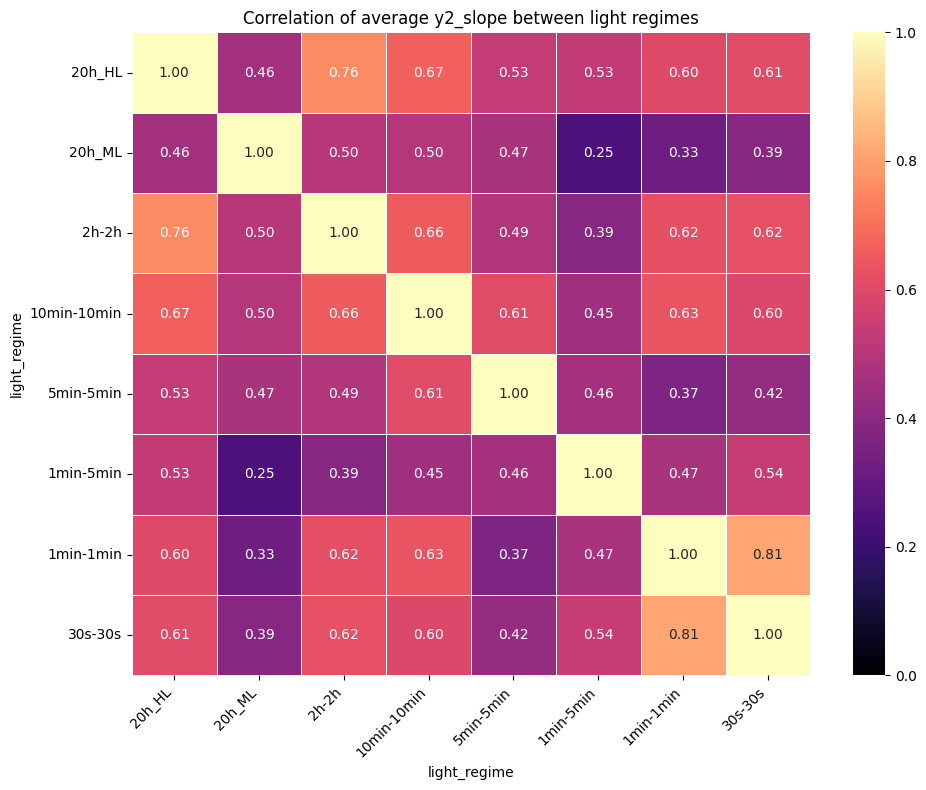

In [ ]:
# Plotting the correlation matrix
Plots.plot_slope_correlation(data, regime_order = ["20h_HL", "2h-2h","10min-10min", "5min-5min", "1min-1min", "30s-30s"])

/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5482.
  res = hypotest_fun_out(*samples, **kwds)


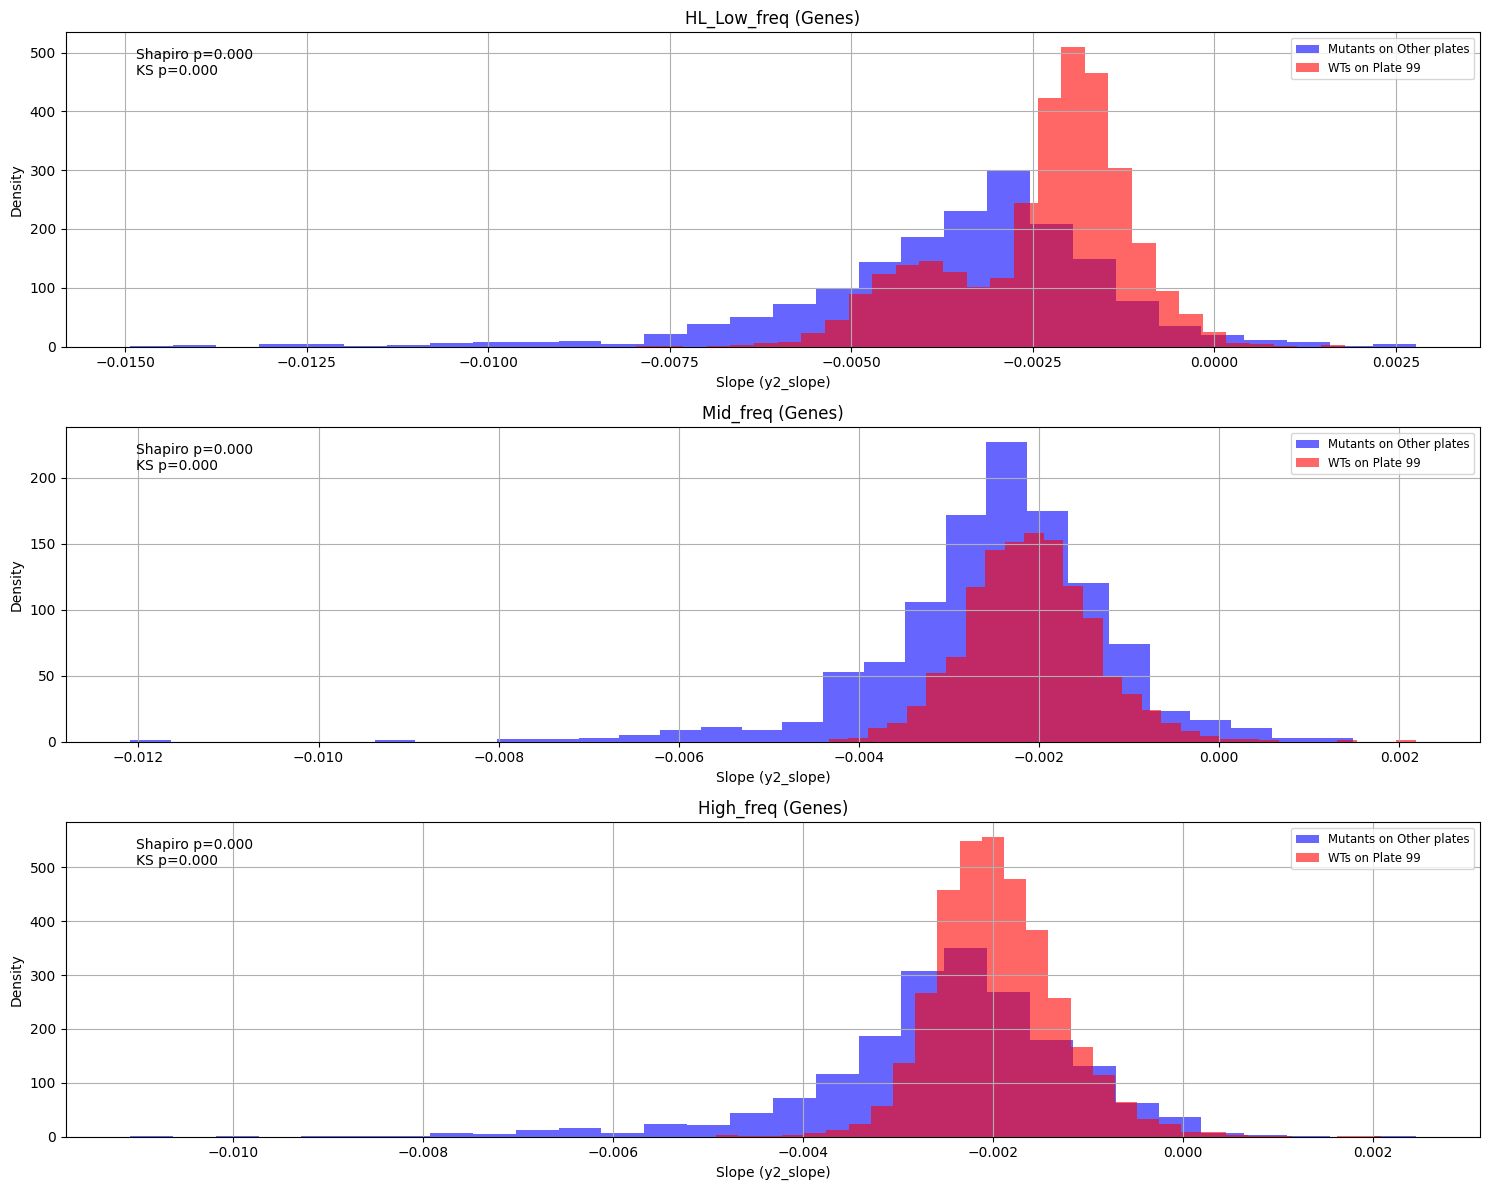

In [ ]:
# Plotting the distribution of wild types vs mutants (in different light blocs defined above)

normalised_wts = data#[(data['mutant_ID'] != 'WT')]# & (data['plate'].astype(str).str.startswith('99'))]

light_regimes = ['HL_Low_freq','Mid_freq','High_freq']

n_rows = 3
n_cols = 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten() 

for i, light_regime in enumerate(light_regimes):
    ax = axes[i]  
    data_light = normalised_wts[normalised_wts['light_bloc'] == light_regime]
    
    # slopes = data_light['y2_slope'].dropna()
    slopes_99 = data_light[data_light['mutated_genes'] == 'WT']['y2_slope'].dropna()    
    slopes_other = data_light[(data_light['mutated_genes'] != 'WT') & (data_light['plate'].astype(str).str.startswith('3'))]
    slopes_other = slopes_other.drop_duplicates(subset=['mutated_genes', 'light_regime'])['y2_slope'].dropna()
    
    if slopes_99.empty and slopes_other.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax.set_title(f'{light_regime}')
        ax.axis('off')
        continue

    if not slopes_other.empty:
        ax.hist(slopes_other, bins=30, alpha=0.6, color='blue', label='Mutants on Other plates')

    if not slopes_99.empty:
        ax.hist(slopes_99, bins=30, alpha=0.6, color='red', label='WTs on Plate 99')

    slopes_combined = pd.concat([slopes_99, slopes_other])
    mean, std = norm.fit(slopes_combined)
    shapiro_stat, shapiro_p = shapiro(slopes_combined)
    ks_stat, ks_p = kstest(slopes_combined, 'norm', args=(mean, std))

    ax.text(0.05, 0.95, f'Shapiro p={shapiro_p:.3f}\nKS p={ks_p:.3f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top')
    
    ax.set_title(f'{light_regime} (Genes)')
    ax.set_xlabel('Slope (y2_slope)')
    ax.set_ylabel('Density')
    ax.legend(fontsize='small')
    ax.grid(True)

for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## IQR 

In [20]:
import pandas as pd
import numpy as np

def detect_outliers_iqr_with_quantile(df, slope_col='y2_slope'):
    regimes = df['light_bloc'].unique()
    outlier_flags = []

    for regime in regimes:
        regime_df = df[df['light_bloc'] == regime].copy()

        # WT only
        wt_slopes = regime_df[regime_df['mutant_ID'] == 'WT'][slope_col].dropna()

        # IQR limits
        Q1 = np.percentile(wt_slopes, 5)
        Q3 = np.percentile(wt_slopes, 95)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Rank WT slopes for ECDF
        wt_sorted = np.sort(wt_slopes)

        # Compute quantile position for each point
        def get_quantile(value):
            return np.searchsorted(wt_sorted, value, side='right') / len(wt_sorted)

        regime_df['is_outlier_IQR'] = (regime_df[slope_col] < lower) | (regime_df[slope_col] > upper)
        regime_df['WT_quantile'] = regime_df[slope_col].apply(get_quantile)

        outlier_flags.append(regime_df)

        print(f"{regime}: Q1={Q1:.3f} Q3={Q3:.3f} IQR={IQR:.3f} Lower={lower:.3f} Upper={upper:.3f}")

    result_df = pd.concat(outlier_flags, ignore_index=True)
    return result_df

# Example usage
result = detect_outliers_iqr_with_quantile(data)

# Show a preview
print(result[['mutant_ID', 'mutated_genes', 'light_bloc', 'y2_slope', 'is_outlier_IQR', 'WT_quantile']].head())


HL_Low_freq: Q1=-0.005 Q3=-0.001 IQR=0.004 Lower=-0.011 Upper=0.005
High_freq: Q1=-0.003 Q3=-0.001 IQR=0.002 Lower=-0.006 Upper=0.002
Mid_freq: Q1=-0.003 Q3=-0.001 IQR=0.002 Lower=-0.007 Upper=0.002
           mutant_ID                                mutated_genes  \
0  LMJ.RY0402.185266  Cre06.g278194 & Cre06.g278195,Cre06.g278194   
1  LMJ.RY0402.043444                                Cre02.g105350   
2  LMJ.RY0402.255196                  Cre02.g095135,Cre01.g036050   
3  LMJ.RY0402.256887  Cre02.g087450,Cre02.g087450 & Cre02.g087500   
4  LMJ.RY0402.041908                                Cre02.g076987   

    light_bloc  y2_slope  is_outlier_IQR  WT_quantile  
0  HL_Low_freq -0.006171           False     0.002162  
1  HL_Low_freq -0.004608           False     0.063948  
2  HL_Low_freq -0.003282           False     0.233550  
3  HL_Low_freq -0.005359           False     0.013284  
4  HL_Low_freq -0.006560           False     0.000927  


In [ ]:
# Suppose `result` is your DataFrame with:
# - mutant_ID
# - mutated_genes
# - light_regime
# - is_outlier_IQR

# Filter mutants outliers
outliers = result[(result['mutant_ID'] != 'WT') & (result['is_outlier_IQR'])]

summary = (
    outliers.groupby('light_regime')
    .agg(
        unique_outlier_mutants = ('mutant_ID', 'nunique'),
        unique_outlier_genes = ('mutated_genes', 'nunique')
    )
    .reset_index()
)

print(summary)


  light_regime  unique_outlier_mutants  unique_outlier_genes
0  10min-10min                      18                    17
1    1min-1min                      34                    33
2    1min-5min                      18                    17
3       20h_HL                      49                    48
4        2h-2h                       2                     2
5      30s-30s                      43                    39
6    5min-5min                      16                    16


In [ ]:
# Save outliers and their quantile % wt distribution
outliers[['mutant_ID', 'mutated_genes', 'light_bloc','light_regime', 'is_outlier_IQR', 'WT_quantile']].to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/DifferentTestGenes/QTILNORM_randeffonTIMEPOINTS_IQR_outliers_light_blocs95%.csv', index=False)

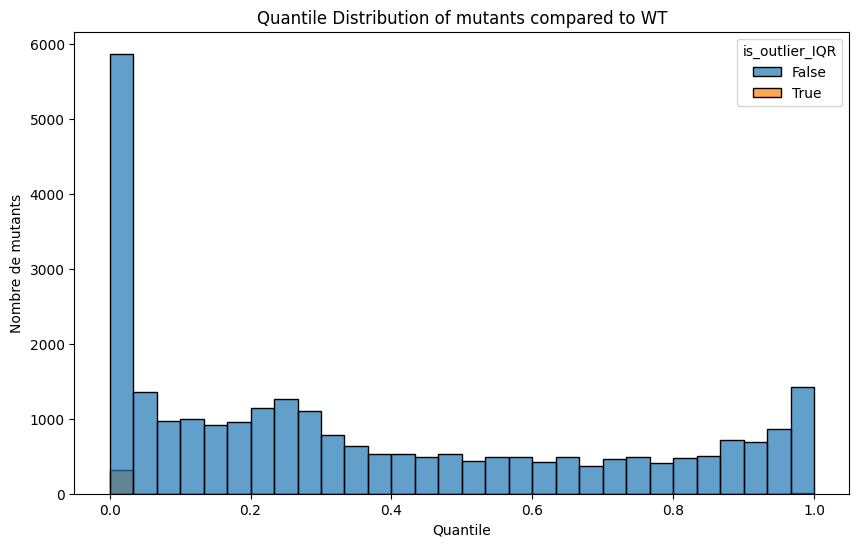

In [ ]:
mutants = result[result['mutant_ID'] != 'WT']

plt.figure(figsize=(10, 6))

sns.histplot(
    data=mutants,
    x='WT_quantile',
    hue='is_outlier_IQR',
    bins=30,
    edgecolor='black',
    alpha=0.7
)

plt.title('Quantile Distribution of mutants compared to WT')
plt.xlabel('Quantile')
plt.ylabel('Nombre de mutants')
plt.show()


## Test (zscore 1 samp t-test)

HL_Low_freq


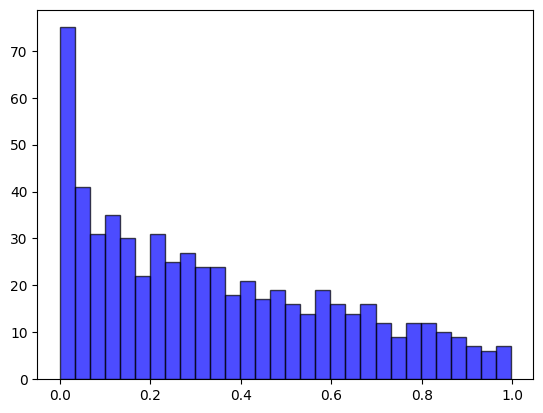

Mid_freq


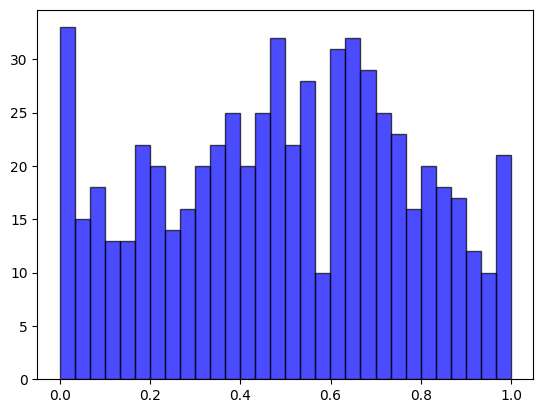

High_freq


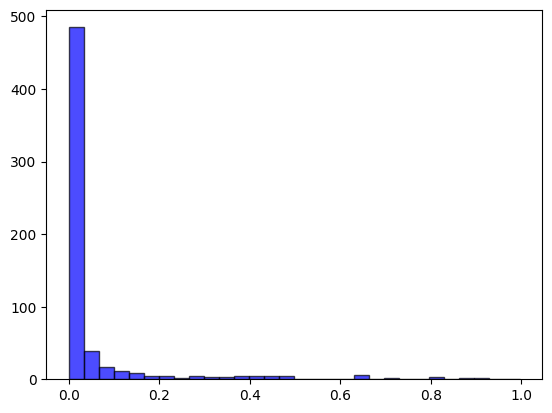

In [ ]:
from scipy.stats import ttest_1samp

def gene_level_ttest(filtered_mutants, wt_df, regime):
    gene_pvals = {}
    gene_zscores = {}
    
    mut_sub = filtered_mutants[filtered_mutants['light_bloc'] == regime]
    wt_sub = wt_df[wt_df['light_bloc'] == regime]
    
    for gene, group in mut_sub.groupby('mutated_genes'):
        deltas = []
        
        for _, row in group.iterrows():
            plate = row['plate']
            mutant_slope = row['y2_slope']
            wt_slopes = wt_sub[wt_sub['plate']==plate]['y2_slope'].values
            
            if len(wt_slopes)<2:
                continue
            wt_mean = np.mean(wt_slopes)
            delta = mutant_slope -wt_mean
            deltas.append(delta)
            
        if len(deltas)<2 or np.std(deltas)<1e-8:
            continue
        t_stat, p_val = ttest_1samp(deltas, popmean=0)
        p_val = max(p_val, 1e-300)
        gene_pvals[gene]=p_val
        z_score = np.sign(t_stat)*norm.ppf(1-p_val/2)
        
        gene_zscores[gene] = z_score
    return gene_zscores, gene_pvals
    
light_blocs = ['HL_Low_freq','Mid_freq','High_freq']


# perform t tests per light bloc
for regime in light_blocs:
    data = data
    # Filter WT and mutant rows
    wt_df = data[data['mutated_genes'].str.startswith('WT')].copy()
    filtered_mutants = data[~data['mutated_genes'].str.startswith('WT')].copy()
    print(regime)
    z_scores, p_values = gene_level_ttest(filtered_mutants, wt_df, regime)
    z_scores_df = pd.DataFrame(list(z_scores.items()), columns = ['mutated_genes', 'z_score'])
    p_val_df = pd.DataFrame(list(p_values.items()), columns = ['mutated_genes', 'p_value'])
    plt.hist(p_val_df['p_value'], bins=30, alpha=0.7,color='blue',edgecolor='black')
    plt.show()
    #z_scores_df.to_csv(f'/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/z_scores_locfdr/{regime}_mutant_zscore.csv', index=False)
        